## ML Project

#### 🏭 Industry  
- E-commerce & Marketing 

#### 🌐 Domain  
- Lifestyle & Consumer Themes  

## 📂 Dataset Information

#### 🔎 Sources
- **GDELT GKG** (Global Knowledge Graph)  
- **Google Trends**  
- **World Bank Open Data (WDI)**
- **Holidays(Python Library)**

#### All the datasets are **open source** and publicly available.  
- ✅ No privacy, licensing, or access restrictions  
- ✅ Safe for research and academic use 

## Loading the Datasets

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import mysql.connector
from rich.console import Console
from warnings import filterwarnings
filterwarnings("ignore")

In [3]:
# initalizing the console for rich output
console = Console()


In [4]:
# connecting to the MySQL database
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="!@Mstrong@1234",
    database="GDELTTrends"
)

In [5]:
# initializing the cursor to execute SQL queries
cursor = connection.cursor()

In [6]:
# getting table names from the database
cursor.execute("SHOW TABLES")

In [7]:
print("Tables in GDELTTrends:")
for table in cursor.fetchall():
    print(table[0])

Tables in GDELTTrends:
gdelt_gkg
google_trends
merged_data


In [8]:
gkg = pd.read_sql("SELECT * FROM gdelt_gkg;", connection)
gtrends = pd.read_sql("SELECT * FROM google_trends;", connection)

In [9]:
gkg.head()

,Week_Start,Country_Code,Category,Media_Volume,tone_net_sentiment,tone_positive_score,tone_negative_score,tone_polarity,tone_activity_density,tone_self_group_density,Source_Diversity
0,2023-01-01,AE,Fashion_Beauty,115,1.401100,4.34705,2.94595,7.29301,21.0569,0.618644,81
1,2023-01-01,AE,Fitness_Wearables,52,-1.598140,3.93978,5.53792,9.47770,18.9000,0.208290,44
2,2023-01-01,AE,Nutrition_Diets,845,1.083790,4.18150,3.09772,7.27922,20.7641,0.583760,329
3,2023-01-01,AU,Fashion_Beauty,172,-1.462470,2.71911,4.18158,6.90069,19.9640,0.394380,144
4,2023-01-01,AU,Fitness_Wearables,13,0.996642,3.45307,2.45642,5.90949,21.0787,0.929115,13


In [10]:
gtrends.head()

,Week_Start,Country_Code,Country_Name,Category,Search_Interest,Search_Velocity,Search_Acceleration
0,2023-01-01,AE,United_Arab_Emirates,Fashion_Beauty,67.23,-13.20,-4.62
1,2023-01-01,AE,United_Arab_Emirates,Fitness_Wearables,72.78,5.97,12.48
2,2023-01-01,AE,United_Arab_Emirates,Nutrition_Diets,74.40,14.84,23.46
3,2023-01-01,AU,Australia,Fashion_Beauty,58.06,-12.50,5.27
4,2023-01-01,AU,Australia,Fitness_Wearables,89.21,25.64,39.61


In [11]:
gkg['Week_Start'] = pd.to_datetime(gkg['Week_Start'], format='%Y-%m-%d')

In [12]:
mergerd_data = pd.merge(gtrends, gkg, on=['Week_Start','Country_Code','Category'], how='left')

In [13]:
mergerd_data.head()

,Week_Start,Country_Code,Country_Name,Category,Search_Interest,Search_Velocity,Search_Acceleration,Media_Volume,tone_net_sentiment,tone_positive_score,tone_negative_score,tone_polarity,tone_activity_density,tone_self_group_density,Source_Diversity
0,2023-01-01,AE,United_Arab_Emirates,Fashion_Beauty,67.23,-13.20,-4.62,115.0,1.401100,4.34705,2.94595,7.29301,21.0569,0.618644,81.0
1,2023-01-01,AE,United_Arab_Emirates,Fitness_Wearables,72.78,5.97,12.48,52.0,-1.598140,3.93978,5.53792,9.47770,18.9000,0.208290,44.0
2,2023-01-01,AE,United_Arab_Emirates,Nutrition_Diets,74.40,14.84,23.46,845.0,1.083790,4.18150,3.09772,7.27922,20.7641,0.583760,329.0
3,2023-01-01,AU,Australia,Fashion_Beauty,58.06,-12.50,5.27,172.0,-1.462470,2.71911,4.18158,6.90069,19.9640,0.394380,144.0
4,2023-01-01,AU,Australia,Fitness_Wearables,89.21,25.64,39.61,13.0,0.996642,3.45307,2.45642,5.90949,21.0787,0.929115,13.0


In [14]:
mergerd_data['Country_Name'].unique()

array(['United_Arab_Emirates', 'Australia', 'Brazil', 'Canada', 'China',
       'Germany', 'France', 'United_Kingdom', 'India', 'Japan', 'Kenya',
       'Mexico', 'Nigeria', 'Singapore', 'United_States', 'South_Africa'],
      dtype=object)

In [15]:
mergerd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Week_Start               9168 non-null   datetime64[ns]
 1   Country_Code             9168 non-null   object        
 2   Country_Name             9168 non-null   object        
 3   Category                 9168 non-null   object        
 4   Search_Interest          9168 non-null   float64       
 5   Search_Velocity          9168 non-null   float64       
 6   Search_Acceleration      9168 non-null   float64       
 7   Media_Volume             7725 non-null   float64       
 8   tone_net_sentiment       7725 non-null   float64       
 9   tone_positive_score      7725 non-null   float64       
 10  tone_negative_score      7725 non-null   float64       
 11  tone_polarity            7725 non-null   float64       
 12  tone_activity_density    7725 non-

In [16]:
mergerd_data.columns

Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity'],
      dtype='object')

## Data Validation

In [17]:
# Required columns/features present?
mergerd_data.columns


Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity'],
      dtype='object')

In [18]:
# Country_name is enough Country_code is not required. So, dropping the country code column.
#mergerd_data = mergerd_data.drop(columns=['Country_Code'])

## ✨ Creating Features

#### 📈 Demand_to_Hype_Ratio  
- **Definition:** Consumer demand (search intent) relative to media volume  
- **Purpose:** Detect whether demand is organic or inflated by media hype  

---

#### 📰 Media_Volume_per_Source  
- **Definition:** Media coverage normalized by source diversity  
- **Purpose:** Measure how concentrated or distributed coverage is across sources  

---

#### 🔍 Interest_per_Source  
- **Definition:** Search demand relative to source count  
- **Purpose:** Identify whether high demand is supported by broad media coverage or limited sources  


In [19]:
df1 = mergerd_data

In [20]:
## Calculating Demand to Hype Ratio
df1['Demand_to_Hype_Ratio'] = (df1['Search_Interest'] /(df1['Media_Volume'] + 1))

In [21]:
df1['Media_Volume_per_Source'] = (df1['Media_Volume'] / (df1['Source_Diversity']))

In [22]:
df1['Interest_per_Source'] = (df1['Search_Interest'] / (df1['Source_Diversity']))

In [23]:
corr = df1.corr(numeric_only=True)

In [24]:
df1.columns

Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity', 'Demand_to_Hype_Ratio',
       'Media_Volume_per_Source', 'Interest_per_Source'],
      dtype='object')

In [25]:
df1.head()

,Week_Start,Country_Code,Country_Name,Category,Search_Interest,Search_Velocity,Search_Acceleration,Media_Volume,tone_net_sentiment,tone_positive_score,tone_negative_score,tone_polarity,tone_activity_density,tone_self_group_density,Source_Diversity,Demand_to_Hype_Ratio,Media_Volume_per_Source,Interest_per_Source
0,2023-01-01,AE,United_Arab_Emirates,Fashion_Beauty,67.23,-13.20,-4.62,115.0,1.401100,4.34705,2.94595,7.29301,21.0569,0.618644,81.0,0.579569,1.419753,0.830000
1,2023-01-01,AE,United_Arab_Emirates,Fitness_Wearables,72.78,5.97,12.48,52.0,-1.598140,3.93978,5.53792,9.47770,18.9000,0.208290,44.0,1.373208,1.181818,1.654091
2,2023-01-01,AE,United_Arab_Emirates,Nutrition_Diets,74.40,14.84,23.46,845.0,1.083790,4.18150,3.09772,7.27922,20.7641,0.583760,329.0,0.087943,2.568389,0.226140
3,2023-01-01,AU,Australia,Fashion_Beauty,58.06,-12.50,5.27,172.0,-1.462470,2.71911,4.18158,6.90069,19.9640,0.394380,144.0,0.335607,1.194444,0.403194
4,2023-01-01,AU,Australia,Fitness_Wearables,89.21,25.64,39.61,13.0,0.996642,3.45307,2.45642,5.90949,21.0787,0.929115,13.0,6.372143,1.000000,6.862308


## ✅ Feature Engineering Status

#### 📊 Summary
- Created sufficient columns for analysis  
- All **required features** and supporting columns are present, if any required will be **created later**.

####  Valid and Realistic Values in the Columns

In [26]:

cat_cols = mergerd_data.select_dtypes(include=object).columns

In [27]:
num_cols = mergerd_data.select_dtypes(include=['float64', 'int64']).columns

In [28]:
for col in cat_cols:
    print(f"{col}:")
    print(f"Number of unique values in '{col}': {len(mergerd_data[col].unique())}\n")
    print(f"Unique values in '{col}': {mergerd_data[col].unique()}\n")
    

Country_Code:
Number of unique values in 'Country_Code': 16

Unique values in 'Country_Code': ['AE' 'AU' 'BR' 'CA' 'CN' 'DE' 'FR' 'GB' 'IN' 'JP' 'KE' 'MX' 'NG' 'SG'
 'US' 'ZA']

Country_Name:
Number of unique values in 'Country_Name': 16

Unique values in 'Country_Name': ['United_Arab_Emirates' 'Australia' 'Brazil' 'Canada' 'China' 'Germany'
 'France' 'United_Kingdom' 'India' 'Japan' 'Kenya' 'Mexico' 'Nigeria'
 'Singapore' 'United_States' 'South_Africa']

Category:
Number of unique values in 'Category': 3

Unique values in 'Category': ['Fashion_Beauty' 'Fitness_Wearables' 'Nutrition_Diets']



In [29]:
for col in cat_cols:
    unique_count = mergerd_data[col].nunique()
    unique_values = mergerd_data[col].unique()
    print(f"Number of unique values in '{col}': {unique_count}")
    display(pd.DataFrame({"Names": unique_values},index=range(1, len(unique_values) + 1)))

Number of unique values in 'Country_Code': 16


,Names
1,AE
2,AU
3,BR
4,CA
5,CN
6,DE
7,FR
8,GB
9,IN
10,JP


Number of unique values in 'Country_Name': 16


,Names
1,United_Arab_Emirates
2,Australia
3,Brazil
4,Canada
5,China
6,Germany
7,France
8,United_Kingdom
9,India
10,Japan


Number of unique values in 'Category': 3


,Names
1,Fashion_Beauty
2,Fitness_Wearables
3,Nutrition_Diets


In [30]:
mergerd_data.describe()

,Week_Start,Search_Interest,Search_Velocity,Search_Acceleration,Media_Volume,tone_net_sentiment,tone_positive_score,tone_negative_score,tone_polarity,tone_activity_density,tone_self_group_density,Source_Diversity,Demand_to_Hype_Ratio,Media_Volume_per_Source,Interest_per_Source
count,9168,9168.000000,9168.000000,9168.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000
mean,2024-10-27 00:00:00,59.570142,-0.030518,0.031242,4951.525566,-0.224535,3.422307,3.646842,7.069150,20.985827,0.584744,813.613074,1.773319,2.570941,2.870058
min,2023-01-01 00:00:00,3.160000,-69.100000,-90.690000,1.000000,-9.980800,0.218818,0.000000,1.162790,11.392400,0.000000,1.000000,0.000326,1.000000,0.004216
25%,2023-11-26 00:00:00,48.302500,-1.990000,-2.900000,43.000000,-1.435080,2.955820,2.889070,6.403830,19.976700,0.427160,30.000000,0.032041,1.378378,0.093975
50%,2024-10-27 00:00:00,64.380000,-0.110000,0.130000,282.000000,-0.317332,3.245330,3.690930,7.093670,21.018200,0.552333,146.000000,0.235993,1.793103,0.444176
75%,2025-09-28 00:00:00,73.990000,1.890000,3.142500,1969.000000,0.735335,3.762470,4.483570,7.709740,22.170800,0.718370,673.000000,1.512245,2.771739,2.222941
max,2026-08-23 00:00:00,100.000000,43.390000,74.170000,168862.000000,10.319000,11.155700,11.802400,13.924100,31.606500,3.898570,12317.000000,47.645000,19.980392,95.290000
std,NaN,20.544332,5.137408,7.387023,18238.421349,1.689364,0.763623,1.179626,1.046579,1.949319,0.271650,1760.765126,4.215094,2.125809,7.675287


### 🌟 Valid and Realistic Values in the Columns

---

### ✅ Overview
- All feature columns contain **valid ranges** consistent with their definitions  
- No unrealistic or out‑of‑scope values detected  

---

### 📊 Value Ranges

| 🏷️ Feature              | 📐 Theoretical Range                  | 🌍 Real-World Range         |
|--------------------------|---------------------------------------|-----------------------------|
| **Search_Interest**      | 0.0 → 100.0                          | 3.0 → 100.0                 |
| **Media_Volume**         | 0 → ∞                                | 1 → 168,862+                |
| **tone_net_sentiment**   | −100.0 → +100.0                      | −10.0 → +10.0               |
| **tone_positive_score**  | 0.0% → 100.0%                        | 0.2% → 11.2%                |
| **tone_negative_score**  | 0.0% → 100.0%                        | 0.0% → 11.8%                |
| **tone_polarity**        | 0.0% → 100.0%                        | 1.1% → 13.9%                |
| **tone_activity_density**| 0.0% → 100.0%                        | 11.3% → 31.6%               |
| **tone_self_group_density** | 0.0% → 100.0%                     | 0.0% → 3.9%                 |
| **Source_Diversity**     | 1 → ∞                                | 1 → 12,317+                 |
 

## Reliable Labels?

In [31]:
# Reliable Labels?
cols = mergerd_data.columns
print(cols)

Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity', 'Demand_to_Hype_Ratio',
       'Media_Volume_per_Source', 'Interest_per_Source'],
      dtype='object')


### ✅  no Problem with the labels

## Correct DataTypes?

In [32]:
mergerd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Week_Start               9168 non-null   datetime64[ns]
 1   Country_Code             9168 non-null   object        
 2   Country_Name             9168 non-null   object        
 3   Category                 9168 non-null   object        
 4   Search_Interest          9168 non-null   float64       
 5   Search_Velocity          9168 non-null   float64       
 6   Search_Acceleration      9168 non-null   float64       
 7   Media_Volume             7725 non-null   float64       
 8   tone_net_sentiment       7725 non-null   float64       
 9   tone_positive_score      7725 non-null   float64       
 10  tone_negative_score      7725 non-null   float64       
 11  tone_polarity            7725 non-null   float64       
 12  tone_activity_density    7725 non-

In [33]:
# Week_Start is a date column, so converting it to datetime format.
mergerd_data['Week_Start'] = pd.to_datetime(mergerd_data['Week_Start'])

### ✅ All datatypes are correct, No problem with datatypes

### 📊 Enough Data

<span style="font-size:16px; font-weight:bold; color:green">
✔ Data covers <b>14 countries</b>, <b>3 categories</b>, and <b>191 weeks</b>  
(~3.7 years of continuous observations)
</span>

<span style="font-size:15px; color:blue">
📈 Total Rows: <b>9,168</b>
</span>


In [34]:
# missing values or Duplicates in the dataset?
mergerd_data.isnull().sum()

Week_Start                    0
Country_Code                  0
Country_Name                  0
Category                      0
Search_Interest               0
Search_Velocity               0
Search_Acceleration           0
Media_Volume               1443
tone_net_sentiment         1443
tone_positive_score        1443
tone_negative_score        1443
tone_polarity              1443
tone_activity_density      1443
tone_self_group_density    1443
Source_Diversity           1443
Demand_to_Hype_Ratio       1443
Media_Volume_per_Source    1443
Interest_per_Source        1443
dtype: int64

In [35]:
mergerd_data.duplicated().sum()

np.int64(0)

In [36]:
# Filter out 'JP' and 'DE' using Country_Code
df_filtered = mergerd_data[~mergerd_data['Country_Code'].isin(['JP', 'DE'])].reset_index(
    drop=True
)
# Verify the updated row count and remaining countries
print(f"Original Row Count : {len(mergerd_data):,}")
print(f"Filtered Row Count : {len(df_filtered):,}")
print(
    f"\nRemaining Countries ({df_filtered['Country_Code'].nunique()} total):"
)
print(sorted(df_filtered['Country_Code'].unique()))
# Save the cleaned dataset
df_filtered.to_csv("master_market_dataset_14countries.csv", index=False)

Original Row Count : 9,168
Filtered Row Count : 8,022

Remaining Countries (14 total):
['AE', 'AU', 'BR', 'CA', 'CN', 'FR', 'GB', 'IN', 'KE', 'MX', 'NG', 'SG', 'US', 'ZA']


## 📊 Data Validation Summary: Google Trends + GDELT GKG

- **Join Type:** Left Join  
- **Dataset Sizes:**  
  - Google Trends → **9168 records**  
  - GDELT GKG → **7725 records**
  - Merged and filtered → **8022 records**
---

### 🔎 Null Value Analysis
- <span style="color:red; font-weight:bold">Total NULL values: 1443</span>  
  *(all columns related to GDELT GKG)*  

- <span style="color:orange; font-weight:bold">Total NULL values after removing Japan & Germany: 1,146</span>  

---
### 🌍 Coverage
- **Countries:** <span style="color:purple; font-weight:bold">14</span>  
  *(AE, AU, BR, CA, CN, FR, GB, IN, KE, MX, NG, SG, US, ZA)*  
- **Categories:** <span style="color:purple; font-weight:bold">3</span> (Lifestyle & Consumer Themes)  
- **Time Span:** <span style="color:purple; font-weight:bold">191 weeks (~3.7 years)</span>  

---
### 🔎 Data Quality
- <span style="color:red; font-weight:bold">Null Values (initial): 1,433</span>  
  *(all GDELT columns)*  
- <span style="color:orange; font-weight:bold">Null Values (after removing Japan & Germany): 1,146</span>  
- **Labels:** Reliable (open‑source datasets)  
- **Restrictions:** None (publicly available, safe for research use)  

---
### ✅ Readiness
- Required features and engineered columns are present  
- Values are valid and realistic  
- Dataset is ready for <span style="color:green; font-weight:bold"> Exploratory Data Analysis</span>  


# Data Undetstanding & EDA

In [37]:
# assigning the merged data to df1 for further analysis
df1 = df_filtered

In [38]:
num_cols = df1.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity', 'Demand_to_Hype_Ratio',
       'Media_Volume_per_Source', 'Interest_per_Source'],
      dtype='object')


# UNIVARIATE ANALYSIS

In [39]:
start_week =df1['Week_Start'].min().strftime('%Y-%m-%d')
End_week = df1['Week_Start'].max().strftime('%Y-%m-%d')

In [40]:
cat_cols = df1.select_dtypes(include=['object']).columns

In [41]:
print(cat_cols)

Index(['Country_Code', 'Country_Name', 'Category'], dtype='object')


In [42]:
# statiscal analysis of the categorical columns in the dataset, for checking class imbalance
def analyze_cat_column(df, column):
    value_counts = df[column].value_counts()
    total_count = len(df)
    percentage = (value_counts / total_count) * 100

    analysis_df = pd.DataFrame({
        'Name': value_counts.index,
        'Count': value_counts.values,
        'Percentage': percentage.values
    }, index=range(1, len(value_counts) + 1))

    return analysis_df

In [43]:
analyze_cat_column(df1, 'Category')

,Name,Count,Percentage
1,Fashion_Beauty,2674,33.333333
2,Fitness_Wearables,2674,33.333333
3,Nutrition_Diets,2674,33.333333


In [44]:
print(f"Descriptive Summary of 'Country_Name' ({start_week} to {End_week}):")
print("Number of unique values in 'Country_Name':", len(df1['Country_Name'].unique()))
print("\nDistribution of 'Country_Name':")
display(analyze_cat_column(df1, 'Country_Name'))

Descriptive Summary of 'Country_Name' (2023-01-01 to 2026-08-23):
Number of unique values in 'Country_Name': 14

Distribution of 'Country_Name':


,Name,Count,Percentage
1,United_Arab_Emirates,573,7.142857
2,Australia,573,7.142857
3,Brazil,573,7.142857
4,Canada,573,7.142857
5,China,573,7.142857
6,France,573,7.142857
7,United_Kingdom,573,7.142857
8,India,573,7.142857
9,Kenya,573,7.142857
10,Mexico,573,7.142857


In [45]:
# function to analyze distribution of numerical columns(Descriptive Statistics)
def analyze_distribution(df, column):
    print(f"Descriptive Summary of {column} ({start_week} to {End_week}):")
    print("="*70)
    range = df[column].max() - df[column].min()
    min_value = df[column].min()
    max_value = df[column].max()
    print(f"Range: {range}")
    print(f"Min - Max: ({min_value} - {max_value})")
    mean_value = df[column].mean()
    print(f"Mean: {mean_value}")
    median_value = df[column].median()
    print(f"Median: {median_value}")
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    print(f"Q1: {q1}, Q3: {q3}")
    IQR = q3 - q1
    print(f"IQR: {IQR}")
    std_value = df[column].std()
    print(f"Standard Deviation: {std_value}")
    skewness_value = df[column].skew()
    print(f"Skewness: {skewness_value}")
    kurtosis_value = df[column].kurtosis()
    print(f"Kurtosis: {kurtosis_value}")
    missing_values = df[column].isnull().sum()
    print(f"Missing Values: {missing_values}")
    lower_outliers = len(df[column][df[column] < (q1 - 1.5 * IQR)])
    upper_outliers = len(df[column][df[column] > (q3 + 1.5 * IQR)])
    print(f"Lower Outliers: {lower_outliers}")
    print(f"Upper Outliers: {upper_outliers}")
    outliers = df[(df[column] < (q1 - 1.5 * IQR)) | (df[column] > (q3 + 1.5 * IQR))]
    print(f"Total Number of Outliers: {outliers.shape[0]}")





In [46]:
def basic_analyze(df, column):
    print("="*70)
    print(f"Descriptive Summary of {column} ({start_week} to {End_week}):")
    print("="*70)
    range = df[column].max() - df[column].min()
    min_value = df[column].min()
    max_value = df[column].max()
    print(f"Range: {range}")
    print(f"Min - Max: ({min_value} - {max_value})")
    mean_value = df[column].mean()
    print(f"Mean: {mean_value}")
    median_value = df[column].median()
    print(f"Median: {median_value}\n")

In [47]:
for col in num_cols:
    basic_analyze(df1, col)

Descriptive Summary of Search_Interest (2023-01-01 to 2026-08-23):
Range: 96.84
Min - Max: (3.16 - 100.0)
Mean: 61.828076539516324
Median: 65.88

Descriptive Summary of Search_Velocity (2023-01-01 to 2026-08-23):
Range: 95.07
Min - Max: (-51.68 - 43.39)
Mean: -0.026406133133881838
Median: -0.12

Descriptive Summary of Search_Acceleration (2023-01-01 to 2026-08-23):
Range: 164.86
Min - Max: (-90.69 - 74.17)
Mean: 0.027035651957117934
Median: 0.14

Descriptive Summary of Media_Volume (2023-01-01 to 2026-08-23):
Range: 168861.0
Min - Max: (1.0 - 168862.0)
Mean: 4951.525566343042
Median: 282.0

Descriptive Summary of tone_net_sentiment (2023-01-01 to 2026-08-23):
Range: 20.2998
Min - Max: (-9.9808 - 10.319)
Mean: -0.2245349161083495
Median: -0.317332

Descriptive Summary of tone_positive_score (2023-01-01 to 2026-08-23):
Range: 10.936881999999999
Min - Max: (0.218818 - 11.1557)
Mean: 3.4223074278317154
Median: 3.24533

Descriptive Summary of tone_negative_score (2023-01-01 to 2026-08-23):


In [48]:
# Descriptive Statistics for Search_Interest
analyze_distribution(df1, 'Search_Interest')

Descriptive Summary of Search_Interest (2023-01-01 to 2026-08-23):
Range: 96.84
Min - Max: (3.16 - 100.0)
Mean: 61.828076539516324
Median: 65.88
Q1: 52.2925, Q3: 74.66
IQR: 22.3675
Standard Deviation: 19.176093488475235
Skewness: -0.8562257427084379
Kurtosis: 0.4920945535893386
Missing Values: 0
Lower Outliers: 333
Upper Outliers: 0
Total Number of Outliers: 333


In [49]:
# Descriptive Statistics for Media_Volume
analyze_distribution(df1, 'Media_Volume')

Descriptive Summary of Media_Volume (2023-01-01 to 2026-08-23):
Range: 168861.0
Min - Max: (1.0 - 168862.0)
Mean: 4951.525566343042
Median: 282.0
Q1: 43.0, Q3: 1969.0
IQR: 1926.0
Standard Deviation: 18238.42134888198
Skewness: 5.916783777198726
Kurtosis: 35.74304825497148
Missing Values: 297
Lower Outliers: 0
Upper Outliers: 1352
Total Number of Outliers: 1352


In [50]:
# Descriptive Statistics for tone_net_sentiment
analyze_distribution(df1, 'tone_net_sentiment')

Descriptive Summary of tone_net_sentiment (2023-01-01 to 2026-08-23):
Range: 20.2998
Min - Max: (-9.9808 - 10.319)
Mean: -0.2245349161083495
Median: -0.317332
Q1: -1.43508, Q3: 0.735335
IQR: 2.1704149999999998
Standard Deviation: 1.6893641798969286
Skewness: 0.3708320407369475
Kurtosis: 1.2791426456477275
Missing Values: 297
Lower Outliers: 44
Upper Outliers: 110
Total Number of Outliers: 154


In [51]:
# Descriptive Statistics for tone_positive_score
analyze_distribution(df1, 'tone_positive_score')

Descriptive Summary of tone_positive_score (2023-01-01 to 2026-08-23):
Range: 10.936881999999999
Min - Max: (0.218818 - 11.1557)
Mean: 3.4223074278317154
Median: 3.24533
Q1: 2.95582, Q3: 3.76247
IQR: 0.8066499999999999
Standard Deviation: 0.7636234471829042
Skewness: 1.3245487750497336
Kurtosis: 5.041870517474418
Missing Values: 297
Lower Outliers: 63
Upper Outliers: 310
Total Number of Outliers: 373


In [52]:
# Descriptive Statistics for tone_negative_score
analyze_distribution(df1, 'tone_negative_score')

Descriptive Summary of tone_negative_score (2023-01-01 to 2026-08-23):
Range: 11.8024
Min - Max: (0.0 - 11.8024)
Mean: 3.6468423752750807
Median: 3.69093
Q1: 2.88907, Q3: 4.48357
IQR: 1.5945000000000005
Standard Deviation: 1.1796264129934557
Skewness: 0.1369751518968973
Kurtosis: 0.9021268245179375
Missing Values: 297
Lower Outliers: 20
Upper Outliers: 56
Total Number of Outliers: 76


In [53]:
# Descriptive Statistics for tone_polarity
analyze_distribution(df1, 'tone_polarity')

Descriptive Summary of tone_polarity (2023-01-01 to 2026-08-23):
Range: 12.76131
Min - Max: (1.16279 - 13.9241)
Mean: 7.069149825242719
Median: 7.09367
Q1: 6.40383, Q3: 7.70974
IQR: 1.30591
Standard Deviation: 1.0465789480494383
Skewness: -0.006916551371589696
Kurtosis: 2.351785417939661
Missing Values: 297
Lower Outliers: 96
Upper Outliers: 70
Total Number of Outliers: 166


In [54]:
# Descriptive Statistics for tone_activity_density
analyze_distribution(df1, 'tone_activity_density')

Descriptive Summary of tone_activity_density (2023-01-01 to 2026-08-23):
Range: 20.214100000000002
Min - Max: (11.3924 - 31.6065)
Mean: 20.985826588996762
Median: 21.0182
Q1: 19.9767, Q3: 22.1708
IQR: 2.194099999999999
Standard Deviation: 1.9493185015497165
Skewness: -0.2569777175099523
Kurtosis: 2.1695636091762864
Missing Values: 297
Lower Outliers: 165
Upper Outliers: 129
Total Number of Outliers: 294


In [55]:
# Descriptive Statistics for tone_self_group_density
analyze_distribution(df1, 'tone_self_group_density')

Descriptive Summary of tone_self_group_density (2023-01-01 to 2026-08-23):
Range: 3.89857
Min - Max: (0.0 - 3.89857)
Mean: 0.5847441430032363
Median: 0.552333
Q1: 0.42716, Q3: 0.71837
IQR: 0.29120999999999997
Standard Deviation: 0.2716501992262028
Skewness: 2.1943650917599022
Kurtosis: 14.920721498235258
Missing Values: 297
Lower Outliers: 0
Upper Outliers: 182
Total Number of Outliers: 182


In [56]:
# Descriptive Statistics for Source_Diversity
analyze_distribution(df1, 'Source_Diversity')

Descriptive Summary of Source_Diversity (2023-01-01 to 2026-08-23):
Range: 12316.0
Min - Max: (1.0 - 12317.0)
Mean: 813.613074433657
Median: 146.0
Q1: 30.0, Q3: 673.0
IQR: 643.0
Standard Deviation: 1760.7651259913198
Skewness: 3.851322287160702
Kurtosis: 16.56963997237124
Missing Values: 297
Lower Outliers: 0
Upper Outliers: 1041
Total Number of Outliers: 1041


# BiVariate Analysis

In [57]:
# Bivariate Analysis: Search_Interest vs Media_Volume
# checking correlation
df1[['Search_Interest', 'Media_Volume']].corr()

,Search_Interest,Media_Volume
Search_Interest,1.000000,-0.094205
Media_Volume,-0.094205,1.000000


In [58]:
cols

Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity', 'Demand_to_Hype_Ratio',
       'Media_Volume_per_Source', 'Interest_per_Source'],
      dtype='object')

In [59]:
# visualizing the correlation between numerical columns
num_corr = df1[num_cols].corr()


In [60]:
import pandas as pd

# Example correlation matrix
corr = df1.corr(numeric_only=True)

# Flattened dictionary without repeats
corr_dict = {
    f"{col1} - {col2}": corr.loc[col1, col2]
    for i, col1 in enumerate(corr.columns)
    for j, col2 in enumerate(corr.columns)
    if j > i   # ensures no repeats and skips self-correlation
}

corr_df = pd.DataFrame(list(corr_dict.items()), columns=['Pair', 'Correlation'])


In [61]:
corr_dict

{'Search_Interest - Search_Velocity': np.float64(0.13138756586071879),
 'Search_Interest - Search_Acceleration': np.float64(0.006419130078122994),
 'Search_Interest - Media_Volume': np.float64(-0.09420462589534315),
 'Search_Interest - tone_net_sentiment': np.float64(0.2230888046851482),
 'Search_Interest - tone_positive_score': np.float64(0.250813692237303),
 'Search_Interest - tone_negative_score': np.float64(-0.15712686843415263),
 'Search_Interest - tone_polarity': np.float64(0.005901385134714805),
 'Search_Interest - tone_activity_density': np.float64(0.04313084766536411),
 'Search_Interest - tone_self_group_density': np.float64(0.07223858055272984),
 'Search_Interest - Source_Diversity': np.float64(-0.1935502901432205),
 'Search_Interest - Demand_to_Hype_Ratio': np.float64(0.1095983600163919),
 'Search_Interest - Media_Volume_per_Source': np.float64(-0.13873672487728253),
 'Search_Interest - Interest_per_Source': np.float64(0.083046074990466),
 'Search_Velocity - Search_Accelerat

<Axes: >

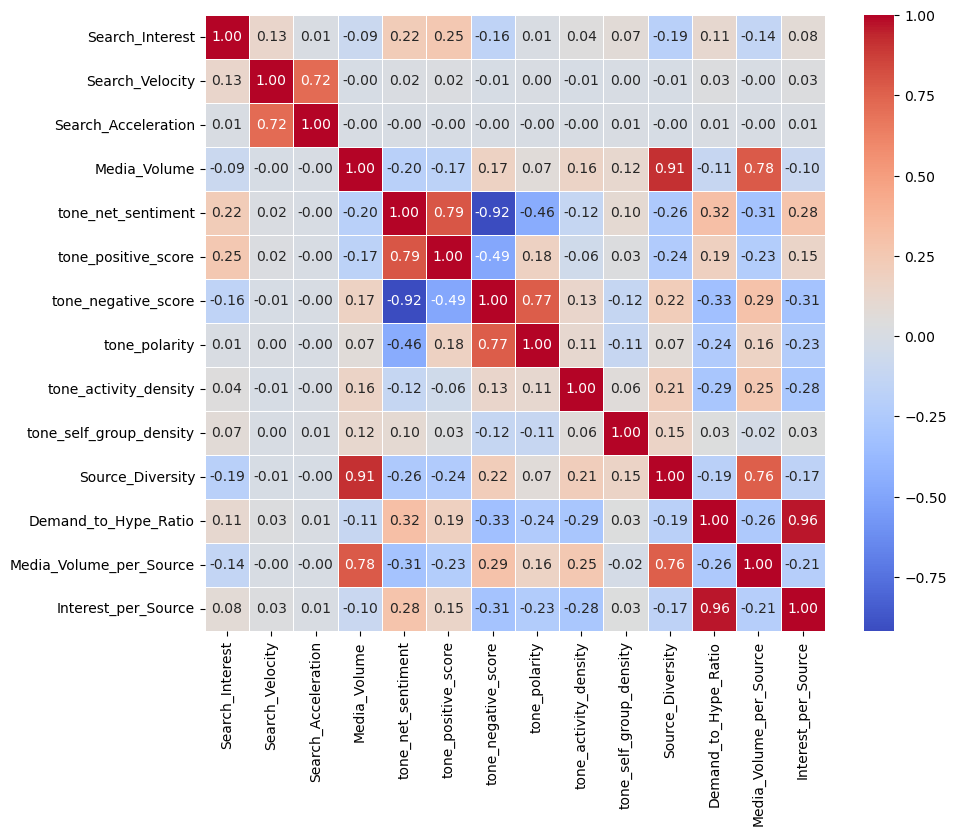

In [62]:
plt.figure(figsize=(10,8))
sns.heatmap(num_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

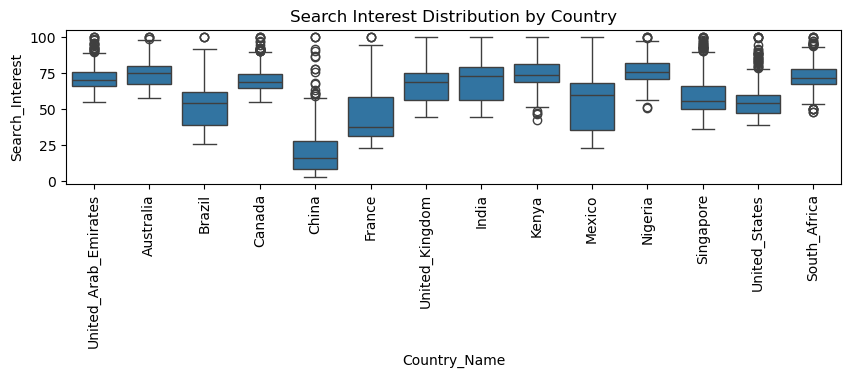

In [63]:
# Search Interest by Country
plt.figure(figsize=(10,2))
sns.boxplot(x='Country_Name', y='Search_Interest', data=df1)
plt.xticks(rotation=90)
plt.title("Search Interest Distribution by Country")
plt.show()


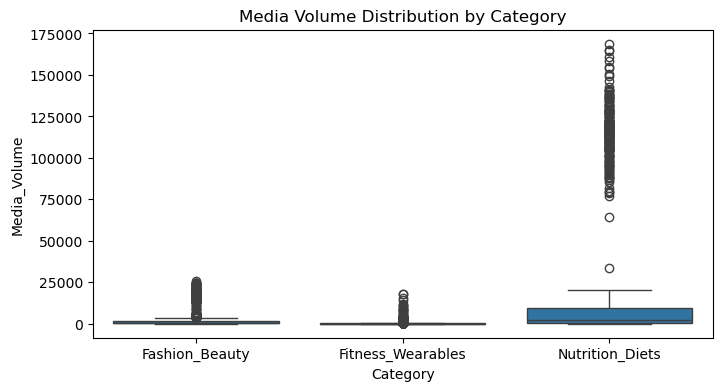

In [64]:
#  Media Volume by Category
plt.figure(figsize=(8,4))
sns.boxplot(x='Category', y='Media_Volume', data=df1)
plt.title("Media Volume Distribution by Category")
plt.show()

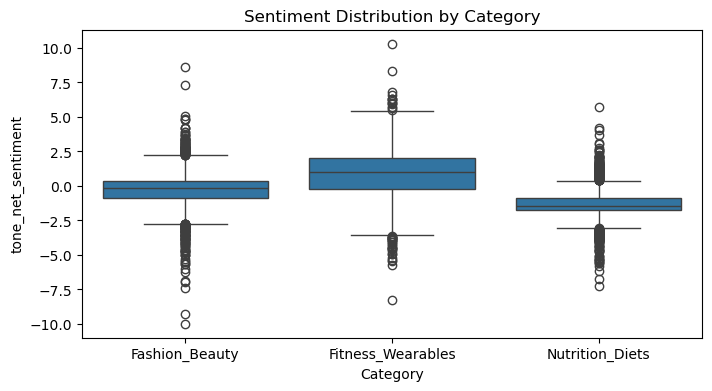

In [65]:
# Sentiment vs Category
plt.figure(figsize=(8,4))
sns.boxplot(x='Category', y='tone_net_sentiment', data=df1)
plt.title("Sentiment Distribution by Category")
plt.show()


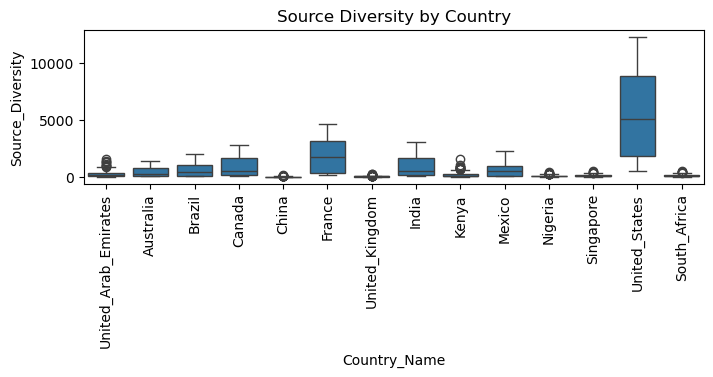

In [66]:
# Source Diversity vs Country
plt.figure(figsize=(8,2))
sns.boxplot(x='Country_Name', y='Source_Diversity', data=df1)
plt.xticks(rotation=90)
plt.title("Source Diversity by Country")
plt.show()

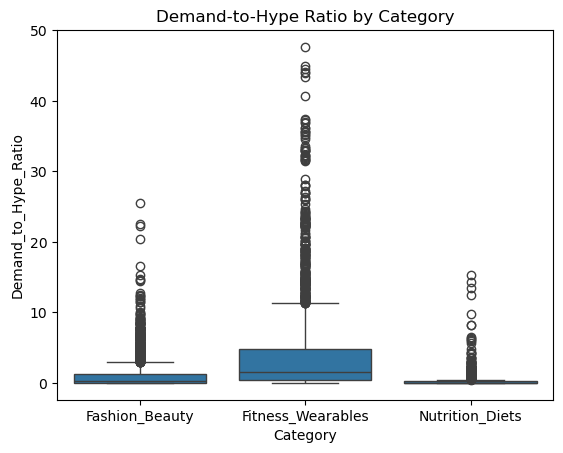

In [67]:
# Demand-to-Hype Ratio vs Category
sns.boxplot(x='Category', y='Demand_to_Hype_Ratio', data=df1)
plt.title("Demand-to-Hype Ratio by Category")
plt.show()

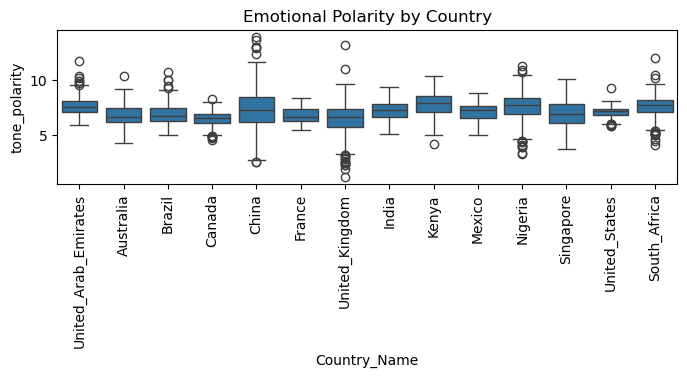

In [68]:
# Emotional Tone vs Country
plt.figure(figsize=(8,2))
sns.boxplot(x='Country_Name', y='tone_polarity', data=df1)
plt.xticks(rotation=90)
plt.title("Emotional Polarity by Country")
plt.show()


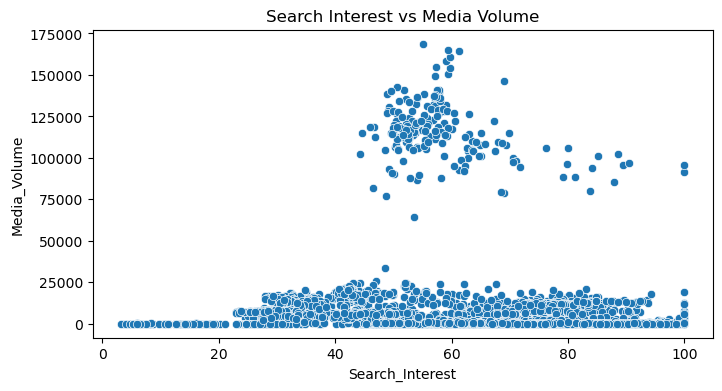

In [69]:
# Seach Interest vs Media Volume
plt.figure(figsize=(8,4))
sns.scatterplot(x='Search_Interest', y='Media_Volume', data=df1)
plt.title("Search Interest vs Media Volume")
plt.show()

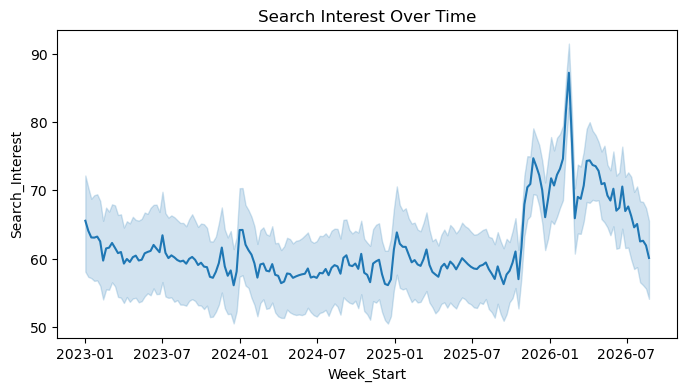

In [70]:
# time series analysis of Search Interest
plt.figure(figsize=(8,4))
sns.lineplot(x='Week_Start', y='Search_Interest', data=df1)
plt.title("Search Interest Over Time")
plt.show()

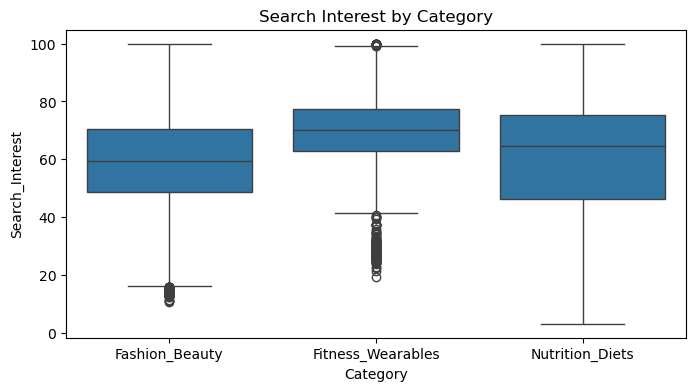

In [71]:
# categories vs Search Interest
plt.figure(figsize=(8,4))
sns.boxplot(x='Category', y='Search_Interest', data=df1)
plt.title("Search Interest by Category")
plt.show()


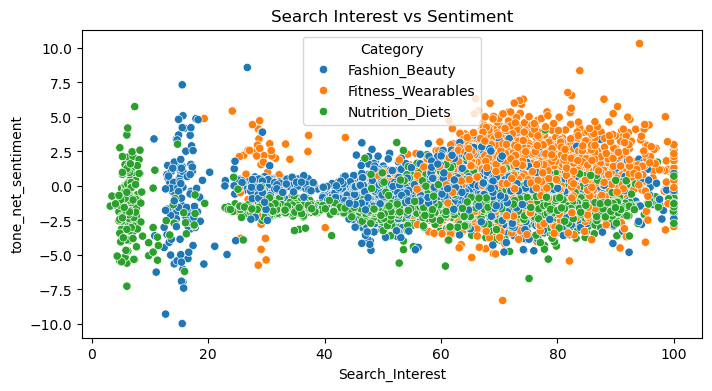

In [75]:
# Search Interest vs tone_net_sentiment
plt.figure(figsize=(8,4))
sns.scatterplot(x='Search_Interest', y='tone_net_sentiment', hue='Category', data=df1)
plt.title("Search Interest vs Sentiment")   
plt.show()

# 📊 Exploratory Data Analysis — Insights

## 📊 Insights from Univariate Analysis
---

## 🔎 1. Public Search & Interest
- **Overall Popularity (Search_Interest):**  
  Public interest is consistently strong, averaging **62–66 / 100**.  
  👉 However, attention is highly volatile — dipping as low as **3** and peaking at **100** during major events.  

- **Speed of Change (Search_Velocity & Search_Acceleration):**  
  Despite large possible swings (velocity range ~95, acceleration range ~165), the **average change is close to zero**.  
  👉 This means interest shifts gradually over time, with stability in the long run.

---

## 📰 2. News & Media Coverage
- **Extreme Spikes in News Volume (Media_Volume):**  
  Typical week → ~**282 articles**.  
  Major events → Surges to **168,000+ articles**, inflating the average to ~**4,951**.  
  👉 Coverage is usually quiet but dominated by rare explosive spikes.  

- **Broad News Outlets (Source_Diversity):**  
  Normal → ~**146 publishers**.  
  Big stories → Expand across **12,000+ outlets**, showing how quickly coverage scales globally.

---

## 💬 3. Media Mood & Tone
- **Slightly Negative Tone (tone_net_sentiment):**  
  Average sentiment leans mildly negative (−0.22), with negative articles (~3.6%) slightly outweighing positive (~3.4%).  

- **Emotional Intensity (tone_polarity):**  
  Emotional language is consistently present (~**7% of words**), rarely neutral.  

- **Action & Social Focus (tone_activity_density & tone_self_group_density):**  
  ~**21%** of content uses active, event‑driven language.  
  References to groups/communities are rare (<**1%**), meaning most reporting is objective.

---

## ⚖️ 4. People vs. Hype Relationships
- **Public Demand vs. News Hype (Demand_to_Hype_Ratio):**  
  Most weeks → News coverage outweighs demand (**median ~0.24**).  
  Quiet weeks → Public interest can outweigh coverage by **up to 47×**, showing rare but powerful demand surges.  

- **Articles per Publisher (Media_Volume_per_Source):**  
  Each outlet publishes ~**2–3 articles per topic per week**, indicating balanced distribution.  

- **Interest per Source:**  
  Median ~**0.44**, meaning search demand is often small compared to the number of sources covering it.

---

## ✅ Key Takeaways
- Public interest is **steady overall but volatile in bursts**.  
- News coverage is **quiet most of the time, but explosively spiky during events**.  
- Sentiment is **slightly negative, emotionally charged, and action‑driven**.  
- Coverage is **widely distributed across publishers**, scaling massively during global events.  
- Demand is often **overshadowed by hype**, but in rare weeks, **public curiosity dominates the narrative**.


## BiVariate Analysis Insights
### 📊 Correlation Analysis Insights

#### 🔵 1. Consumer Demand & Search Momentum

- 🟡 **Search Interest ↔ Search Velocity (r = 0.131)**  
  → Current search demand has only a weak relationship with the speed at which demand is changing.

- ⚪ **Search Interest ↔ Search Acceleration (r = 0.006)**  
  → Current demand level has virtually no linear relationship with whether search momentum is accelerating or decelerating.

- 🔵 **Search Velocity ↔ Search Acceleration (r = 0.721)**  
  → Search velocity and acceleration have a strong positive relationship, indicating that periods of rapid demand movement tend to coincide with stronger changes in momentum.

💡 **Business Insight:** Search Interest, Velocity, and Acceleration capture different dimensions of demand. Current demand level alone does not explain future momentum.

---

#### 🟠 2. Consumer Demand vs Media Coverage

- 🔴 **Search Interest ↔ Media Volume (r = -0.094)**  
  → Consumer search interest and overall media coverage have almost no linear relationship.

- 🟡 **Search Interest ↔ Source Diversity (r = -0.194)**  
  → Higher search interest is weakly associated with lower source diversity.

- 🟡 **Search Interest ↔ Media Volume per Source (r = -0.139)**  
  → Higher search interest tends to be associated with slightly lower media activity per source.

- ⚪ **Search Interest ↔ Interest per Source (r = 0.083)**  
  → Search interest has almost no relationship with its source-normalized version.

💡 **Business Insight:** Consumer demand appears to operate relatively independently from the scale and breadth of media coverage.

---

#### 🟢 3. Consumer Demand & Positive/Negative Sentiment

- 🟢 **Search Interest ↔ Positive Score (r = 0.251)**  
  → Higher consumer interest has a modest positive association with positive media tone.

- 🟢 **Search Interest ↔ Net Sentiment (r = 0.223)**  
  → More positive overall media sentiment is moderately associated with higher consumer search interest.

- 🔴 **Search Interest ↔ Negative Score (r = -0.157)**  
  → Higher search interest is weakly associated with lower negative media tone.

- ⚪ **Search Interest ↔ Tone Polarity (r = 0.006)**  
  → Overall tone polarity has virtually no linear relationship with search interest.

💡 **Business Insight:** Consumer interest appears to have a somewhat stronger relationship with **positive media sentiment** than with negative sentiment or overall polarity.

---

#### 🟣 4. Search Momentum vs Media & Sentiment

- ⚪ **Search Velocity ↔ Media Volume (r = -0.005)**  
  → Changes in search demand are essentially unrelated to the amount of media coverage.

- ⚪ **Search Velocity ↔ Net Sentiment (r = 0.017)**  
  → Search momentum has almost no relationship with media sentiment.

- ⚪ **Search Velocity ↔ Positive Score (r = 0.021)**  
  → Positive media tone does not meaningfully explain changes in search velocity.

- ⚪ **Search Velocity ↔ Negative Score (r = -0.011)**  
  → Negative media tone has virtually no relationship with search velocity.

- ⚪ **Search Acceleration ↔ Media Volume (r = -0.003)**  
  → Acceleration in search demand is essentially independent of media volume.

- ⚪ **Search Acceleration ↔ Net Sentiment (r = -0.001)**  
  → Search acceleration shows virtually no linear relationship with media sentiment.

💡 **Business Insight:** Media sentiment and media volume do not appear to explain short-term changes in consumer search momentum.

---

#### 🟠 5. Media Volume & Source Breadth

- 🟢 **Media Volume ↔ Source Diversity (r = 0.915)**  
  → Media volume has a very strong positive relationship with source diversity.

- 🟢 **Media Volume ↔ Media Volume per Source (r = 0.782)**  
  → Higher total media coverage is strongly associated with higher media volume per source.

- 🟡 **Media Volume ↔ Negative Score (r = 0.172)**  
  → Greater media coverage is weakly associated with more negative media tone.

- 🟡 **Media Volume ↔ Net Sentiment (r = -0.197)**  
  → Higher media volume is weakly associated with lower net sentiment.

- 🟡 **Media Volume ↔ Positive Score (r = -0.171)**  
  → Higher media volume is weakly associated with lower positive tone.

- 🟡 **Media Volume ↔ Activity Density (r = 0.156)**  
  → Greater media volume is modestly associated with higher activity density.

- 🟡 **Media Volume ↔ Self/Group Density (r = 0.120)**  
  → Media volume has a weak positive association with self/group-oriented language.

💡 **Business Insight:** Higher media coverage is associated with broader source participation, but it does **not necessarily mean more positive coverage**. In fact, greater coverage shows a slight tendency toward more negative tone.

---

#### 🔴 6. Media Volume & Demand-to-Hype Relationship

- 🟡 **Media Volume ↔ Demand-to-Hype Ratio (r = -0.113)**  
  → Higher media volume is weakly associated with a lower demand-to-hype ratio.

- 🔴 **Media Volume ↔ Interest per Source (r = -0.100)**  
  → Higher media volume is weakly associated with lower search interest relative to source breadth.

💡 **Business Insight:** Increasing media coverage does not necessarily correspond to increasing consumer demand; high media activity can occur without proportional search interest.

---

#### 🟢 7. Net Sentiment Relationships

- 🟢 **Net Sentiment ↔ Positive Score (r = 0.793)**  
  → Positive media tone strongly contributes to higher net sentiment.

- 🔴 **Net Sentiment ↔ Negative Score (r = -0.919)**  
  → Negative media tone has a very strong inverse relationship with net sentiment.

- 🟠 **Net Sentiment ↔ Tone Polarity (r = -0.457)**  
  → Net sentiment and polarity have a moderate negative relationship in this dataset.

- 🟡 **Net Sentiment ↔ Activity Density (r = -0.119)**  
  → Higher activity density is weakly associated with lower net sentiment.

- 🟡 **Net Sentiment ↔ Source Diversity (r = -0.257)**  
  → Greater source diversity is modestly associated with lower net sentiment.

💡 **Business Insight:** Negative media tone appears to have a stronger relationship with overall net sentiment than positive tone, while broader source participation is slightly associated with less favorable sentiment.

---

#### 🟣 8. Positive vs Negative Media Tone

- 🟠 **Positive Score ↔ Negative Score (r = -0.488)**  
  → Positive and negative media tone have a moderate inverse relationship.

- 🟡 **Positive Score ↔ Tone Polarity (r = 0.180)**  
  → Positive tone has only a weak relationship with polarity.

- 🟡 **Negative Score ↔ Tone Polarity (r = 0.771)**  
  → Negative tone has a strong relationship with polarity in this dataset.

⚠️ **Important EDA Check:**  
The strong positive correlation between `tone_negative_score` and `tone_polarity` may appear counterintuitive depending on how your GDELT tone variables are defined. Verify the exact calculation/definition of `tone_polarity` before presenting this as a business conclusion.

---

#### 🟠 9. Media Activity Density

- 🟡 **Activity Density ↔ Source Diversity (r = 0.212)**  
  → More diverse source participation is modestly associated with higher media activity density.

- 🟡 **Activity Density ↔ Demand-to-Hype Ratio (r = -0.287)**  
  → Higher media activity density tends to be associated with a lower demand-to-hype ratio.

- 🟡 **Activity Density ↔ Media Volume per Source (r = 0.254)**  
  → Higher activity density is modestly associated with greater media activity per source.

- 🟡 **Activity Density ↔ Interest per Source (r = -0.278)**  
  → Higher media activity density tends to coincide with lower search interest per source.

💡 **Business Insight:** Highly active media environments do not necessarily correspond to stronger consumer demand and may indicate greater media attention relative to search interest.

---

#### 🟡 10. Self/Group Media Density

- 🟡 **Self/Group Density ↔ Source Diversity (r = 0.153)**  
  → Greater source diversity has a weak positive relationship with self/group-oriented media language.

- ⚪ **Self/Group Density ↔ Demand-to-Hype Ratio (r = 0.033)**  
  → Virtually no relationship exists between self/group language and the demand-to-hype relationship.

- ⚪ **Self/Group Density ↔ Interest per Source (r = 0.034)**  
  → Self/group language has almost no relationship with source-adjusted consumer interest.

💡 **Business Insight:** Self/group-oriented language appears largely independent of consumer demand and media hype.

---

#### 🔴 11. Demand-to-Hype Ratio

- 🟣 **Demand-to-Hype Ratio ↔ Interest per Source (r = 0.963)**  
  → These metrics move almost identically.

⚠️ **Critical Feature Engineering Finding:**  
The extremely high correlation indicates substantial redundancy between `Demand_to_Hype_Ratio` and `Interest_per_Source`.

- 🟡 **Demand-to-Hype Ratio ↔ Negative Score (r = -0.332)**  
  → Higher negative media tone is moderately associated with a lower demand-to-hype ratio.

- 🟡 **Demand-to-Hype Ratio ↔ Net Sentiment (r = 0.316)**  
  → More positive net sentiment is moderately associated with a higher demand-to-hype ratio.

- 🟡 **Demand-to-Hype Ratio ↔ Activity Density (r = -0.287)**  
  → Higher media activity density is associated with lower demand-to-hype levels.

- 🟡 **Demand-to-Hype Ratio ↔ Tone Polarity (r = -0.238)**  
  → Demand-to-hype levels show a weak-to-moderate inverse relationship with tone polarity.

💡 **Business Insight:** Demand appears stronger relative to media hype when sentiment is more favorable and weaker when negative media activity increases.

---

#### 🟢 12. Interest per Source

- 🟣 **Interest per Source ↔ Demand-to-Hype Ratio (r = 0.963)**  
  → Strong evidence that these metrics contain highly overlapping information.

- 🟡 **Interest per Source ↔ Negative Score (r = -0.307)**  
  → Higher negative media tone is moderately associated with lower interest per source.

- 🟡 **Interest per Source ↔ Net Sentiment (r = 0.283)**  
  → More favorable sentiment is associated with somewhat higher interest per source.

- 🟡 **Interest per Source ↔ Activity Density (r = -0.278)**  
  → Higher media activity density is associated with lower interest per source.

- 🟡 **Interest per Source ↔ Tone Polarity (r = -0.235)**  
  → Interest per source has a weak-to-moderate inverse relationship with tone polarity.

---

#### ⚠️ 13. Feature Redundancy & Multicollinearity Findings

Several very strong correlations should be treated as **feature dependencies rather than independent business discoveries**:

| Correlation | r | Interpretation |
|---|---:|---|
| 🟣 Demand-to-Hype ↔ Interest per Source | **0.963** | Very high redundancy |
| 🔴 Net Sentiment ↔ Negative Score | **-0.919** | Strong feature dependency |
| 🟢 Media Volume ↔ Source Diversity | **0.915** | Strong structural relationship |
| 🟢 Net Sentiment ↔ Positive Score | **0.793** | Strong overlap |
| 🟢 Media Volume ↔ Media Volume per Source | **0.782** | Strong derived-feature dependency |
| 🟢 Negative Score ↔ Tone Polarity | **0.771** | Strong relationship |
| 🟢 Source Diversity ↔ Media Volume per Source | **0.764** | Strong relationship |
| 🔵 Search Velocity ↔ Search Acceleration | **0.721** | Strong momentum relationship |

💡 **Modeling Insight:** Before using these features in a machine-learning model, check **VIF, feature definitions, and mathematical dependencies**. Highly correlated derived variables may unnecessarily increase multicollinearity.

---

#### 🎯 Overall Business Conclusion

> 🟢 **Consumer search demand shows little relationship with overall media volume, but has a modest positive association with positive media sentiment and a weak negative association with negative sentiment. Media coverage, meanwhile, is strongly associated with source diversity, indicating that broader source participation drives higher media volume. Negative media tone has a particularly strong relationship with declining net sentiment, while high media activity does not necessarily translate into stronger consumer demand.**



---

## 🌍 Search Interest Distribution by Country

---

### 🔎 Key Observations

🔵 **Consistently High Interest Countries**
- United States, India, and the United Kingdom show relatively high median search interest.
- 👉 Public interest remains strong and relatively consistent in these regions.

🟠 **High Variability Countries**
- Brazil, Mexico, and Nigeria show wider spreads and more extreme values.
- 👉 Public interest fluctuates more sharply, with periods of both low and very high engagement.

🟢 **Stable Interest Countries**
- Australia, Canada, and France show tighter distributions.
- 👉 Search interest remains relatively steady with fewer extreme changes.

🟡 **Lower Interest Countries**
- China, Kenya, and South Africa show comparatively lower median interest.
- 👉 Public search engagement appears less consistently high in these markets.

🔴 **Global Peaks**
- Nearly all countries show occasional values reaching close to **100**.
- 👉 Major global events can create sudden spikes in interest across multiple regions.

---

### 💡 What It Means

Search interest follows different patterns across countries. Some markets maintain consistently high engagement, while others experience stronger event-driven fluctuations.

---

### ✅ Takeaway

> 🌍 **Global events can create widespread peaks in interest, but the consistency and volatility of public engagement vary significantly across countries.**

---

## 📰 Media Volume Distribution by Category

---

### 🔎 Key Observations

🔴 **Nutrition & Diets**
- Shows the highest median media volume.
- Also has the widest spread and the largest extreme spikes.
- 👉 This category receives intense media attention during major events and trending topics.

🟣 **Fashion & Beauty**
- Shows a lower median media volume.
- Coverage is relatively more stable with fewer extreme spikes.
- 👉 Media attention is steadier and less event-driven.

🔵 **Fitness & Wearables**
- Shows moderate media coverage.
- The distribution is relatively stable compared with Nutrition & Diets.
- 👉 Coverage experiences fewer major reporting spikes.

---

### 💡 What It Means

Health and diet-related topics appear to attract stronger and more unpredictable media attention compared with Fashion and Fitness topics.

---

### ✅ Takeaway

> 📰 **Nutrition & Diets is the most media-sensitive category, while Fashion & Beauty and Fitness & Wearables receive more stable levels of coverage.**

---

## 💬 Sentiment Distribution by Category

---

### 🔎 Key Observations

🔴 **Nutrition & Diets**
- Shows the widest range of sentiment values.
- Sentiment moves between strongly negative and strongly positive.
- 👉 Diet-related topics generate more mixed and emotionally varied discussions.

🟠 **Fashion & Beauty**
- Shows a slightly negative median sentiment.
- The distribution is relatively narrow.
- 👉 Media tone is more consistent and less extreme.

🟢 **Fitness & Wearables**
- Sentiment remains close to neutral overall.
- Shows moderate variation with occasional extreme values.
- 👉 Coverage is generally balanced.

---

### 💡 What It Means

Different categories generate different emotional reactions. Nutrition topics create the most mixed and polarized discussions, while Fitness and Fashion show more stable sentiment patterns.

---

### ✅ Takeaway

> 💬 **Nutrition & Diets generates the most varied sentiment, while Fashion & Beauty and Fitness & Wearables maintain relatively more stable media tone.**

---

## 🌐 Source Diversity by Country

---

### 🔎 Key Observations

🔵 **United States**
- Shows the highest source diversity and the widest range.
- 👉 Topics receive coverage from a large number of different publishers.

🟢 **Moderate Diversity Countries**
- United Kingdom, India, Canada, and Australia show moderate levels of source diversity.
- 👉 Coverage comes from a reasonably broad range of media sources.

🟡 **Lower Diversity Countries**
- Nigeria, Singapore, and Kenya show lower diversity levels.
- 👉 Coverage is concentrated among fewer publishers.

🟠 **Occasional Diversity Spikes**
- Some countries experience sudden increases in source diversity.
- 👉 Major events can temporarily attract attention from a broader range of publishers.

---

### 💡 What It Means

Media coverage is not equally distributed across countries. Larger media markets generally attract coverage from more diverse sources.

---

### ✅ Takeaway

> 🌐 **Source diversity varies significantly across countries, with major media markets receiving broader coverage and smaller markets relying on fewer publishers.**

---

## ⚖️ Demand-to-Hype Ratio by Category

---

### 🔎 Key Observations

🔴 **Fitness & Wearables**
- Shows the widest variation and the highest number of extreme values.
- Some periods show public demand rising far beyond media attention.
- 👉 Consumer interest can increase suddenly and unpredictably.

🟠 **Nutrition & Diets**
- Shows a relatively lower median ratio with occasional spikes.
- 👉 Media attention often exceeds consumer demand, although certain events generate strong public curiosity.

🟢 **Fashion & Beauty**
- Shows a narrower and more stable distribution.
- 👉 Consumer demand and media attention remain relatively balanced.

---

### 💡 What It Means

The relationship between consumer demand and media attention differs by category. Some categories experience strong demand spikes without matching media coverage.

---

### ✅ Takeaway

> ⚖️ **Fitness & Wearables is the most unpredictable, Nutrition & Diets is relatively more media-driven, and Fashion & Beauty shows the most balanced demand-to-hype relationship.**

---

## 💫 Emotional Polarity by Country

---

### 🔎 Key Observations

🔴 **United States**
- Shows one of the highest levels and widest ranges of emotional polarity.
- 👉 Media coverage tends to contain stronger emotional variation.

🟠 **Moderate Polarity Countries**
- United Kingdom, India, Brazil, and Mexico show moderate polarity levels.
- 👉 Coverage contains emotional language but remains relatively balanced.

🟢 **Lower Polarity Countries**
- China, Singapore, Nigeria, and Kenya show lower and more stable polarity levels.
- 👉 Coverage appears relatively less emotionally intense.

🟡 **Occasional Emotional Spikes**
- Several countries show sudden increases in polarity.
- 👉 Major events can trigger more emotionally charged reporting.

---

### 💡 What It Means

Media tone differs across countries. Some markets show stronger emotional reactions to events, while others maintain more stable reporting patterns.

---

### ✅ Takeaway

> 💫 **Emotional intensity varies across countries, with some markets showing stronger reactions to events and others maintaining relatively stable media tone.**

---

## 🔗 Search Interest vs Media Volume

---

### 🔎 Key Observations

🔵 **Different Levels of Media Response**
- Many observations show low media volume across different levels of search interest.
- Some observations show sharp increases in media coverage at moderate search interest levels.
- 👉 Media attention does not increase consistently with consumer interest.

🟠 **Possible Non-Linear Pattern**
- Media volume does not appear to rise proportionally as search interest increases.
- 👉 Consumer demand and media attention may follow different patterns rather than a simple one-to-one relationship.

🔴 **High Media Volume Outliers**
- Some observations show very high media coverage despite only moderate search interest.
- 👉 External events, breaking news, or controversy may generate media attention without equally strong consumer demand.

---

### 💡 What It Means

A high level of public interest does not automatically guarantee high media coverage, and high media coverage does not always reflect strong consumer demand.

---

### ✅ Takeaway

> 🔗 **Media attention and consumer demand do not always move together, creating opportunities to identify cases where hype exceeds genuine public interest.**

---

### 🎯 Strategic Implication

- Monitor situations where **media coverage rises faster than search interest**.
- Identify events where **consumer demand grows without matching media attention**.
- 👉 These gaps can help identify potential opportunities, emerging trends, or hype-driven events.

---

## ⏳ Search Interest Over Time

---

### 🔎 Key Observations

🔵 **Regular Fluctuations**
- Search interest rises and falls throughout the observed period.
- 👉 Public attention appears to be influenced by events and changing trends rather than following a perfectly stable pattern.

🔴 **Noticeable Peak in Early 2026**
- A significant increase in search interest appears during early 2026.
- 👉 This may indicate a major event or trend that attracted increased public attention.

🟢 **Sustained Baseline Interest**
- Search interest remains relatively active even outside major peaks.
- 👉 Consumer engagement continues during quieter periods.

🟠 **Changing Variability**
- Some periods show greater variation than others.
- 👉 Public interest can become more unpredictable during major events or emerging trends.

---

### 💡 What It Means

Consumer interest changes over time and appears to be influenced by specific events and trends rather than following a simple continuous pattern.

---

### ✅ Takeaway

> ⏳ **Search interest remains consistently active but experiences noticeable event-driven peaks that create temporary surges in consumer attention.**

---

### 🎯 Strategic Implication

- Monitor sudden increases in search interest to identify emerging trends.
- Compare search spikes with media volume and sentiment.
- 👉 This can help determine whether media coverage follows, leads, or differs from consumer demand.

---

## 🎯 Search Interest by Category

---

### 🔎 Key Observations

🔴 **Nutrition & Diets**
- Shows the highest median search interest.
- Also displays wider variation and frequent high peaks.
- 👉 Public curiosity is strong but can change significantly during major trends or events.

🟠 **Fitness & Wearables**
- Shows moderate search interest.
- Experiences occasional increases but fewer extreme spikes.
- 👉 Consumer engagement is relatively steady with periodic bursts of attention.

🟢 **Fashion & Beauty**
- Shows comparatively lower search interest.
- The distribution is more stable with fewer extreme peaks.
- 👉 Public attention is more consistent but generally less intense.

---

### 💡 What It Means

Consumer interest differs across categories. Health and diet topics generate the strongest overall curiosity, while other lifestyle categories maintain more stable levels of engagement.

---

### ✅ Takeaway

> 🎯 **Nutrition & Diets attracts the strongest and most variable consumer interest, Fitness & Wearables shows moderate engagement, and Fashion & Beauty remains relatively stable at lower interest levels.**

---

# 📈 Overall EDA Summary

---

### 🔎 Key Patterns Identified

🔵 **Consumer Demand**
- Search interest varies significantly across countries and categories.
- Major events can create sudden global or regional spikes.

🟠 **Media Attention**
- Media volume is highly uneven across categories.
- Nutrition & Diets receives the largest and most unpredictable coverage spikes.

🟢 **Sentiment**
- Media tone differs by category.
- Nutrition-related topics generate the greatest variation in sentiment.

🟣 **Geographical Differences**
- Countries differ in both consumer interest and source diversity.
- Larger media markets generally show broader publisher participation.

🔴 **Demand vs Hype**
- Consumer demand and media attention do not always move together.
- Some topics receive significant coverage without matching levels of public interest.

---

### 🏆 Final Business Takeaway

> 🚀 **The analysis shows that consumer demand, media attention, sentiment, and source diversity are interconnected but do not always move together. Understanding the gaps between what the media covers and what people actively search for can help identify emerging opportunities, hype-driven events, and category-specific trends.**
